In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
#from torchvision import datasets, transforms, utils
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import ParameterSampler, RandomizedSearchCV, cross_val_score
#from scipy.stats import uniform
from retriever import *
import random
np.random.seed(32)
random.seed(32)
import skopt
from skopt import gp_minimize
from sklearn.model_selection import ParameterSampler, cross_val_score

In [30]:
#Test for request
print(request_location(8,8))

{'results': [{'elevation': 61.34899139404297, 'location': {'lat': 8, 'lng': 8}, 'resolution': 9.543951988220215}], 'status': 'OK'}


### Data retrivel

In [31]:
start = (54,58)
end = (8,15)
#area = request_elevation_area(start, end, 50)
area = {(54.0, 8.0): -30, (54.08163265306123, 8.142857142857142): -18, (54.16326530612245, 8.285714285714286): -16, (54.244897959183675, 8.428571428571429): -9.03537368774414, (54.326530612244895, 8.571428571428571): 0, (54.40816326530612, 8.714285714285714): -0.01181178819388151, (54.48979591836735, 8.857142857142858): -1, (54.57142857142857, 9.0): -1, (54.6530612244898, 9.142857142857142): 18.92743492126465, (54.734693877551024, 9.285714285714286): 24, (54.816326530612244, 9.428571428571429): 0, (54.89795918367347, 9.571428571428571): 2.141496658325195, (54.97959183673469, 9.714285714285714): 20.19146347045898, (55.06122448979592, 9.857142857142858): -3.238455533981323, (55.142857142857146, 10.0): 1.234527230262756, (55.224489795918366, 10.142857142857142): 41.74970245361328, (55.30612244897959, 10.285714285714285): 18.06439971923828, (55.38775510204081, 10.428571428571429): 15.73514747619629, (55.46938775510204, 10.571428571428571): 40.82516479492188, (55.55102040816327, 10.714285714285715): -1.605897307395935, (55.63265306122449, 10.857142857142858): -15.53832244873047, (55.714285714285715, 11.0): 0.002998791169375181, (55.795918367346935, 11.142857142857142): -12.63070487976074, (55.87755102040816, 11.285714285714285): -14, (55.95918367346939, 11.428571428571429): 8.42130184173584, (56.04081632653061, 11.571428571428571): -18.83854866027832, (56.12244897959184, 11.714285714285715): -21.01815414428711, (56.20408163265306, 11.857142857142858): -24.26643371582031, (56.285714285714285, 12.0): -31, (56.36734693877551, 12.142857142857142): -34.27528381347656, (56.44897959183673, 12.285714285714285): -29.50276184082031, (56.53061224489796, 12.428571428571429): -30, (56.61224489795919, 12.571428571428571): -22, (56.69387755102041, 12.714285714285715): 25.6071605682373, (56.775510204081634, 12.857142857142858): 39.28334045410156, (56.857142857142854, 13.0): 134.6513366699219, (56.93877551020408, 13.142857142857142): 133.4641418457031, (57.02040816326531, 13.285714285714285): 152.8367614746094, (57.10204081632653, 13.428571428571429): 181.2979583740234, (57.183673469387756, 13.571428571428571): 150.7835845947266, (57.265306122448976, 13.714285714285715): 175.9743957519531, (57.3469387755102, 13.857142857142858): 279.8223266601562, (57.42857142857143, 14.0): 245.3598022460938, (57.51020408163265, 14.142857142857142): 202.6801910400391, (57.59183673469388, 14.285714285714285): 207.7731628417969, (57.673469387755105, 14.428571428571429): 275.8136596679688, (57.755102040816325, 14.571428571428571): 280.1349487304688, (57.83673469387755, 14.714285714285715): 312.3470764160156, (57.91836734693877, 14.857142857142858): 260.7734375, (58.0, 15.0): 248.5481414794922}

### Bayesian optimization

In [32]:
#Setup

altitude_range = (12.505247, 12.615981)
latitude_range = (55.776345,55.820256)

domain = {
    "latitude": latitude_range,
    "altitude": altitude_range,
}

x0 = [np.random.choice(latitude_range),np.random.choice(altitude_range)]
y0 = request_elevation(x0[0],x0[1])

In [43]:
global i
i = 1
# What we want to maximize
def objective_function(x): 
    
    elevation = request_elevation(x[0],x[1])
    global i
    i += 1
    print(f"\n\n index = {i}, x = {x}, elevation = {elevation}")

    
    return - elevation


np.int = int #numpy np.int deprecation workaround

opt = gp_minimize(objective_function, # the function to minimize
                  [latitude_range, altitude_range],
                                      # the bounds on each dimension of x
                  acq_func="EI",      # the acquisition function
                  n_initial_points=0, # no initial point except the one
                  n_calls=499,         # the number of evaluations of objective_function 19 since we give one initial point
                  x0=x0,           #initial point
                  y0=[y0],           #inital objective function value
                  xi=0.1,             #exploration parameter
                  noise=0.01**2)       # the noise level (optional)



 index = 2, x = [55.776345, 12.505247], elevation = 31.12199783325195


 index = 3, x = [55.77675673225626, 12.50865933060647], elevation = 34.89870452880859


 index = 4, x = [55.778233394908774, 12.520897529201982], elevation = 44.03496932983398


 index = 5, x = [55.781973136758836, 12.615981], elevation = -2.312006235122681


 index = 6, x = [55.820256, 12.532925432290092], elevation = 22.63022613525391


 index = 7, x = [55.776345, 12.533018275504753], elevation = 44.90741348266602


 index = 8, x = [55.776345, 12.5272502224143], elevation = 38.2213249206543


 index = 9, x = [55.777706776407584, 12.544870735610488], elevation = 47.99711990356445


 index = 10, x = [55.78200918543079, 12.5138086070531], elevation = 46.7219352722168


 index = 11, x = [55.781476747862285, 12.532842173441665], elevation = 39.83560562133789


 index = 12, x = [55.776345, 12.545178781068318], elevation = 49.98606491088867


 index = 13, x = [55.776345, 12.55906096991357], elevation = 36.512241363525

In [44]:
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
y_bo

array([ 4.65222406, 31.12199783, 34.89870453, 44.03496933, 44.03496933,
       44.03496933, 44.90741348, 44.90741348, 47.9971199 , 47.9971199 ,
       47.9971199 , 49.98606491, 49.98606491, 49.98606491, 49.98606491,
       49.98606491, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.25587082, 52.25587082, 52.25587082, 52.25587082,
       52.25587082, 52.86221695, 52.86221695, 55.8489151 , 55.8489151 ,
       55.8489151 , 55.8489151 , 55.8489151 , 55.8489151 , 55.84

In [45]:
-opt.func_vals.ravel()

array([ 4.65222406e+00,  3.11219978e+01,  3.48987045e+01,  4.40349693e+01,
       -2.31200624e+00,  2.26302261e+01,  4.49074135e+01,  3.82213249e+01,
        4.79971199e+01,  4.67219353e+01,  3.98356056e+01,  4.99860649e+01,
        3.65122414e+01,  2.97040043e+01,  3.36296349e+01,  2.19365845e+01,
        5.22558708e+01,  3.46956253e+01,  3.59081459e+01,  3.13228989e+01,
       -0.00000000e+00,  2.56882172e+01,  1.55553093e+01,  4.03731384e+01,
        3.45460167e+01,  4.94242134e+01,  5.14983482e+01,  4.20157471e+01,
        4.84959793e+01, -0.00000000e+00,  1.39219570e+01,  5.19147415e+01,
        3.10428581e+01,  2.25179310e+01,  3.82197990e+01,  3.81676750e+01,
        3.75689125e+01,  2.33646088e+01,  3.09904881e+01, -1.15426302e+00,
        3.93315544e+01,  3.77344170e+01,  2.66139450e+01,  3.16803989e+01,
        2.60166950e+01,  3.41207848e+01,  1.24052172e+01,  4.46783485e+01,
        1.80597858e+01,  4.11393623e+01,  2.66299725e+01,  4.92888527e+01,
        1.35993805e+01,  

In [46]:
altitude_range = (12.505247, 12.615981)
latitude_range = (55.776345,55.820256)

domain = {
    "latitude": uniform(loc=55.776345, scale=55.820256 - 55.776345),
    "altitude": uniform(loc=12.505247, scale=12.615981 - 12.505247),
}

param_list = list(ParameterSampler(domain,n_iter=500,random_state=32))
print(param_list)

[{'altitude': np.float64(12.600355244124428), 'latitude': np.float64(55.79271111952612)}, {'altitude': np.float64(12.566718630102896), 'latitude': np.float64(55.81830883472278)}, {'altitude': np.float64(12.586821371266176), 'latitude': np.float64(55.81218538386357)}, {'altitude': np.float64(12.516440719169216), 'latitude': np.float64(55.817115839659685)}, {'altitude': np.float64(12.572696094719083), 'latitude': np.float64(55.80254025793361)}, {'altitude': np.float64(12.515410624382524), 'latitude': np.float64(55.79150247312978)}, {'altitude': np.float64(12.578636237902433), 'latitude': np.float64(55.795741080991824)}, {'altitude': np.float64(12.56631544853855), 'latitude': np.float64(55.80724571921105)}, {'altitude': np.float64(12.570513755946942), 'latitude': np.float64(55.778537597398696)}, {'altitude': np.float64(12.56745645760334), 'latitude': np.float64(55.80999656688042)}, {'altitude': np.float64(12.60611552297743), 'latitude': np.float64(55.7804247686756)}, {'altitude': np.float

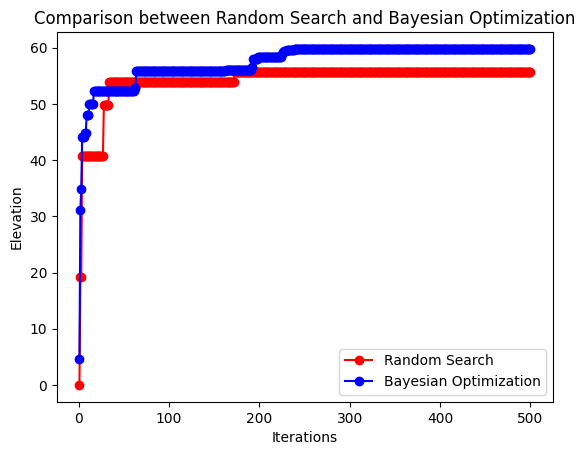

In [47]:
random_elevation = []
for param in param_list:
    random_elevation.append(request_elevation(param["latitude"],param["altitude"]))

max_cumulative_elevation_per_iteration = np.maximum.accumulate(random_elevation)
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
# define iteration number
xs = np.arange(1,len(random_elevation) + 1,1)


plt.plot(xs, max_cumulative_elevation_per_iteration, 'o-', color = 'red', label='Random Search')
plt.plot(xs, y_bo, 'o-', color = 'blue', label='Bayesian Optimization')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Elevation')
plt.title('Comparison between Random Search and Bayesian Optimization')
plt.show()

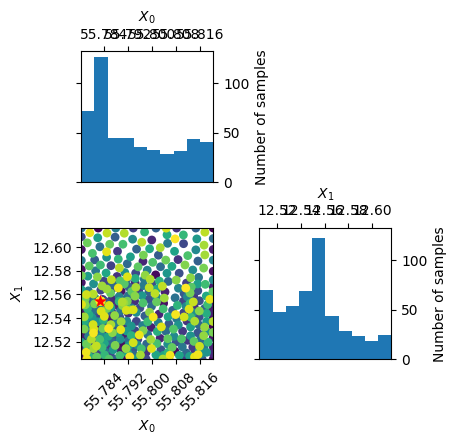

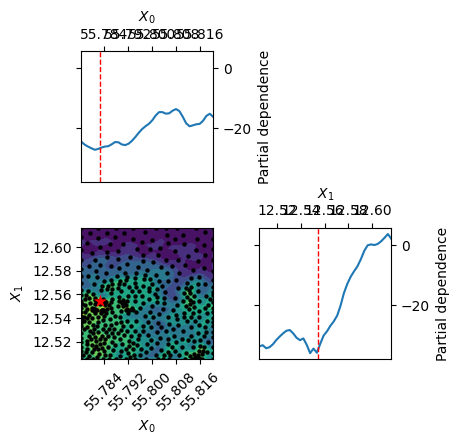

In [48]:
from skopt.plots import plot_objective, plot_evaluations

# 1. Shows where the optimizer spent most of its time
plot_evaluations(opt, bins=10)
plt.show()

# 2. Shows the predicted landscape (the surrogate model)
plot_objective(opt)
plt.show()

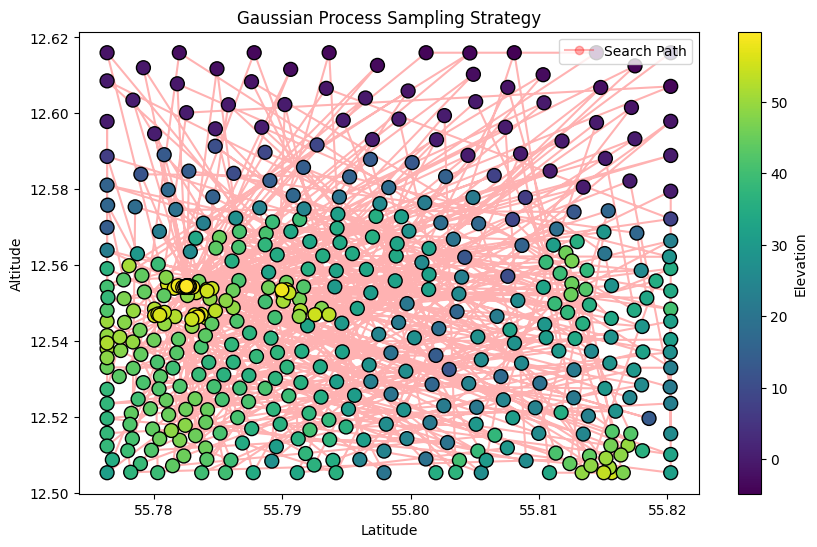

In [49]:
import matplotlib.pyplot as plt

# Extract the points sampled (x) and the results (y)
# opt.x_iters is a list of [lat, alt] pairs
# opt.func_vals is the elevation (negative because of the objective function)
sampled_points = np.array(opt.x_iters)
elevations = -opt.func_vals  # Convert back to positive elevation

plt.figure(figsize=(10, 6))
# Plot the path of the optimizer
plt.plot(sampled_points[:, 0], sampled_points[:, 1], 'ro-', alpha=0.3, label='Search Path')
# Scatter plot colored by elevation to see where the high points are
sc = plt.scatter(sampled_points[:, 0], sampled_points[:, 1], 
                 c=elevations, cmap='viridis', s=100, edgecolors='k', zorder=5)

plt.colorbar(sc, label='Elevation')
plt.xlabel('Latitude')
plt.ylabel('Altitude')
plt.title('Gaussian Process Sampling Strategy')
plt.legend()
plt.show()